In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

# Set style
# plt.style.use('default')
plt.style.use("ggplot")
sns.set_palette("husl")

# Set figure parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [2]:
import matplot2tikz

In [3]:
STATIC_POOL_DIR = "final"
LEARN_POOL_DIR = "final_2"

In [4]:
def load_data(pool_dir):
    # Get all strategy directories
    strategy_dirs = [d for d in pool_dir.iterdir() if d.is_dir() and not d.name.startswith('analysis')]
    strategy_dirs = sorted(strategy_dirs, key=lambda x: int(x.name.split('_')[0]))

    print(f"Found {len(strategy_dirs)} strategy directories:")
    for d in strategy_dirs:
        print(f"  {d.name}")

    # Get noise levels from one directory
    sample_rep_dir = strategy_dirs[0] / 'repetition_0'
    csv_files = [f for f in sample_rep_dir.iterdir() if f.suffix == '.csv']
    noise_levels = sorted([float(f.stem) for f in csv_files])
    print(f"\nNoise levels: {noise_levels}")

    # Number of repetitions
    rep_dirs = [d for d in strategy_dirs[0].iterdir() if d.name.startswith('repetition_')]
    n_repetitions = len(rep_dirs)
    print(f"Number of repetitions: {n_repetitions}")

    def load_tournament_data():
        """
        Load all tournament data from the final directory structure.
        Returns a comprehensive DataFrame with all results.
        """
        all_data = []
        
        for strategy_dir in strategy_dirs:
            strategy_id = int(strategy_dir.name.split('_')[0])
            strategy_name = '_'.join(strategy_dir.name.split('_')[1:])
            
            print(f"Loading data for {strategy_dir.name}...")
            
            for rep in range(n_repetitions):
                rep_dir = strategy_dir / f'repetition_{rep}'
                
                # Load player names from details.json
                details_file = rep_dir / 'details.json'
                if details_file.exists():
                    with open(details_file, 'r') as f:
                        details = json.load(f)
                        player_names = details['player_names']
                else:
                    player_names = None
                
                for noise_level in noise_levels:
                    csv_file = rep_dir / f'{noise_level}.csv'
                    
                    if csv_file.exists():
                        try:
                            df = pd.read_csv(csv_file)
                            
                            # Add metadata columns
                            df['strategy_id'] = strategy_id
                            df['strategy_name'] = strategy_name
                            df['testing_strategy'] = f"{strategy_id}_{strategy_name}"
                            df['noise_level'] = noise_level
                            df['repetition_id'] = rep
                            
                            # Add player names if available
                            if player_names:
                                df['player_name_clean'] = df['Player index'].map(
                                    lambda x: player_names[x] if x < len(player_names) else f"Player_{x}"
                                )
                                df['opponent_name_clean'] = df['Opponent index'].map(
                                    lambda x: player_names[x] if x < len(player_names) else f"Player_{x}"
                                )
                            
                            all_data.append(df)
                            
                        except Exception as e:
                            print(f"Error loading {csv_file}: {e}")
        
        # Combine all data
        full_df = pd.concat(all_data, ignore_index=True)
        print(f"\nLoaded {len(full_df)} total interactions")
        
        return full_df
    tournament_data = load_tournament_data()
    return tournament_data

In [5]:
static_tournament_results = load_data(Path(STATIC_POOL_DIR))
static_tournament_results.head()

Found 15 strategy directories:
  0_DBS
  1_RiskyQLearner
  2_ArrogantQLearner
  3_CautiousQLearner
  4_HesitantQLearner
  5_JaxFiveStateAgent
  6_JaxFiveStateAgent
  7_JaxFactorizedAgent
  8_JaxFactorizedAgent
  9_APavlov2011
  10_AdaptiveTitForTat
  11_GTFT
  12_ContriteTitForTat
  13_StochasticWSLS
  14_WinStayLoseShift

Noise levels: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Number of repetitions: 5
Loading data for 0_DBS...
Loading data for 1_RiskyQLearner...
Loading data for 2_ArrogantQLearner...
Loading data for 3_CautiousQLearner...
Loading data for 4_HesitantQLearner...
Loading data for 5_JaxFiveStateAgent...
Loading data for 6_JaxFiveStateAgent...
Loading data for 7_JaxFactorizedAgent...
Loading data for 8_JaxFactorizedAgent...
Loading data for 9_APavlov2011...
Loading data for 10_AdaptiveTitForTat...
Loading data for 11_GTFT...
Loading data for 12_ContriteTitForTat...
Loading data for 13_StochasticWSLS...
Loading data for 14_WinStayLoseShift...

Loaded 256500 to

,Interaction index,Player index,Opponent index,Repetition,Player name,Opponent name,Actions,Score,Score difference,Turns,...,DD to D count,Good partner,Intended Actions,strategy_id,strategy_name,testing_strategy,noise_level,repetition_id,player_name_clean,opponent_name_clean
0,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
1,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
2,1,0,1,0,"DBS: 0.75, 3, 4, 3, 5",Cooperator,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Cooperator
3,1,1,0,0,Cooperator,"DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,Cooperator,"DBS: 0.75, 3, 4, 3, 5"
4,2,0,2,0,"DBS: 0.75, 3, 4, 3, 5",Defector,CCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,1496,-20,1500,...,1495,1,CCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Defector


In [6]:
learn_tournament_results = load_data(Path(LEARN_POOL_DIR))
learn_tournament_results.head()

Found 15 strategy directories:
  0_DBS
  1_RiskyQLearner
  2_ArrogantQLearner
  3_CautiousQLearner
  4_HesitantQLearner
  5_JaxFiveStateAgent
  6_JaxFiveStateAgent
  7_JaxFactorizedAgent
  8_JaxFactorizedAgent
  9_APavlov2011
  10_AdaptiveTitForTat
  11_GTFT
  12_ContriteTitForTat
  13_StochasticWSLS
  14_WinStayLoseShift

Noise levels: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Number of repetitions: 5
Loading data for 0_DBS...
Loading data for 1_RiskyQLearner...
Loading data for 2_ArrogantQLearner...
Loading data for 3_CautiousQLearner...
Loading data for 4_HesitantQLearner...
Loading data for 5_JaxFiveStateAgent...
Loading data for 6_JaxFiveStateAgent...
Loading data for 7_JaxFactorizedAgent...
Loading data for 8_JaxFactorizedAgent...
Loading data for 9_APavlov2011...
Loading data for 10_AdaptiveTitForTat...
Loading data for 11_GTFT...
Loading data for 12_ContriteTitForTat...
Loading data for 13_StochasticWSLS...
Loading data for 14_WinStayLoseShift...

Loaded 67500 tot

,Interaction index,Player index,Opponent index,Repetition,Player name,Opponent name,Actions,Score,Score difference,Turns,...,DD to D count,Good partner,Intended Actions,strategy_id,strategy_name,testing_strategy,noise_level,repetition_id,player_name_clean,opponent_name_clean
0,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
1,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
2,1,0,1,0,"DBS: 0.75, 3, 4, 3, 5",Adaptive Pavlov 2006,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Adaptive Pavlov 2006
3,1,1,0,0,Adaptive Pavlov 2006,"DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,Adaptive Pavlov 2006,"DBS: 0.75, 3, 4, 3, 5"
4,2,0,2,0,"DBS: 0.75, 3, 4, 3, 5",Adaptive Pavlov 2011,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Adaptive Pavlov 2011


In [7]:
def calculate_average_scores(tournament_data):
    """
    Calculate average scores for each testing strategy across all repetitions and opponents.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    # Calculate average scores per testing strategy, noise level, and opponent
    avg_scores = testing_performance.groupby([
        'testing_strategy', 'noise_level', 'Opponent index', 'opponent_name_clean'
    ]).agg({
        'Score': 'mean',
        'Score per turn': 'mean',
        'Win': 'mean',
        'Cooperation count': 'mean',
        'Turns': 'mean'
    }).reset_index()
    
    # Calculate overall average across all opponents for each testing strategy and noise level
    overall_avg = testing_performance.groupby([
        'testing_strategy', 'noise_level'
    ]).agg({
        'Score': 'mean',
        'Score per turn': 'mean', 
        'Win': 'mean',
        'Cooperation count': 'mean'
    }).reset_index()
    
    return avg_scores, overall_avg


In [8]:
avg_scores_detailed, avg_scores_overall = calculate_average_scores(
    static_tournament_results
)

print("Average scores calculated!")
print(f"Detailed averages shape: {avg_scores_detailed.shape}")
print(f"Overall averages shape: {avg_scores_overall.shape}")

Average scores calculated!
Detailed averages shape: (2700, 9)
Overall averages shape: (150, 6)


In [9]:
avg_scores_detailed, avg_scores_overall = calculate_average_scores(
    learn_tournament_results
)

print("Average scores calculated!")
print(f"Detailed averages shape: {avg_scores_detailed.shape}")
print(f"Overall averages shape: {avg_scores_overall.shape}")

Average scores calculated!
Detailed averages shape: (1350, 9)
Overall averages shape: (150, 6)


In [28]:
def calculate_average_scores_with_ci(tournament_data):
    """
    Calculate average scores for each testing strategy across all repetitions and opponents,
    including 95% confidence intervals.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    # First, calculate the average score per turn for each repetition
    rep_avg_scores = testing_performance.groupby(
        ['testing_strategy', 'noise_level', 'repetition_id']
    )['Score per turn'].mean().reset_index()

    # Now, calculate the mean, std, and count over the repetitions
    
    def agg_with_ci(x):
        mean = x.mean()
        std = x.std(ddof=1) # Use ddof=1 for sample standard deviation
        n = x.count()
        if n > 1:
            # Calculate 95% confidence interval
            se = std / np.sqrt(n)
            # t-distribution critical value for 95% CI
            t_crit = stats.t.ppf(0.975, df=n-1)
            ci_lower = mean - t_crit * se
            ci_upper = mean + t_crit * se
        else:
            se = np.nan
            t_crit = np.nan
            ci_lower = mean
            ci_upper = mean
            
        return pd.Series({
            'mean_score': mean,
            'std_dev': std,
            'n_reps': n,
            'se': se,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

    
    # The result of apply can sometimes be a stacked series. We unstack it.
    overall_avg_with_ci = rep_avg_scores.groupby(
        ['testing_strategy', 'noise_level']
    )['Score per turn'].apply(agg_with_ci).unstack().reset_index()
    
    return overall_avg_with_ci

def plot_score_vs_noise_with_ci(avg_scores_df, title=""):
    """
    Plot average scores per testing strategy against noise level, with 95% CI error bars.
    """
    plt.figure(figsize=(15, 10))
    
    # Use a color palette
    palette = sns.color_palette("husl", len(avg_scores_df['testing_strategy'].unique()))
    
    for i, strategy in enumerate(avg_scores_df['testing_strategy'].unique()):
        print(strategy)
        if strategy not in [
            "0_DBS", 
            # "12_ContriteTitForTat",
            "4_HesitantQLearner",
            # "5_JaxFiveStateAgent",
            "6_JaxFiveStateAgent",
            # "7_JaxFactorizedAgent",
            # "8_JaxFactorizedAgent",
            # "9_APavlov2011",
            
        ]:
            continue
        strategy_data = avg_scores_df[avg_scores_df['testing_strategy'] == strategy]
        
        # Calculate the error size from the confidence interval for plt.errorbar
        y_error = strategy_data['mean_score'] - strategy_data['ci_lower']
        
        plt.errorbar(x=strategy_data['noise_level'], 
                     y=strategy_data['mean_score'], 
                     yerr=y_error,
                     label=strategy,
                     marker='o',
                     linestyle='-',
                     capsize=3, # Add caps to the error bars for visibility
                    #  color=palette[i]
                     )

    plt.title(f'Average Score per Turn vs. Noise Level (with 95% CI)\n{title}')
    plt.xlabel('Noise Level')
    plt.ylabel('Average Score per Turn')
    plt.legend(title='Testing Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    matplot2tikz.clean_figure()
    matplot2tikz.save(f"{title}_score_vs_noise.tex")
    plt.tight_layout()
    plt.show()


  testing_strategy  noise_level  mean_score   std_dev  n_reps        se  \
0            0_DBS         0.00    2.679621  0.046357     5.0  0.020732   
1            0_DBS         0.05    2.493305  0.009040     5.0  0.004043   
2            0_DBS         0.10    2.455789  0.038981     5.0  0.017433   
3            0_DBS         0.15    2.430274  0.030307     5.0  0.013554   
4            0_DBS         0.20    2.396456  0.040859     5.0  0.018273   

   ci_lower  ci_upper  
0  2.622061  2.737181  
1  2.482081  2.504530  
2  2.407388  2.504191  
3  2.392643  2.467905  
4  2.345723  2.447190  
0_DBS
10_AdaptiveTitForTat
11_GTFT
12_ContriteTitForTat
13_StochasticWSLS
14_WinStayLoseShift
1_RiskyQLearner
2_ArrogantQLearner
3_CautiousQLearner
4_HesitantQLearner
5_JaxFiveStateAgent
6_JaxFiveStateAgent
7_JaxFactorizedAgent
8_JaxFactorizedAgent
9_APavlov2011


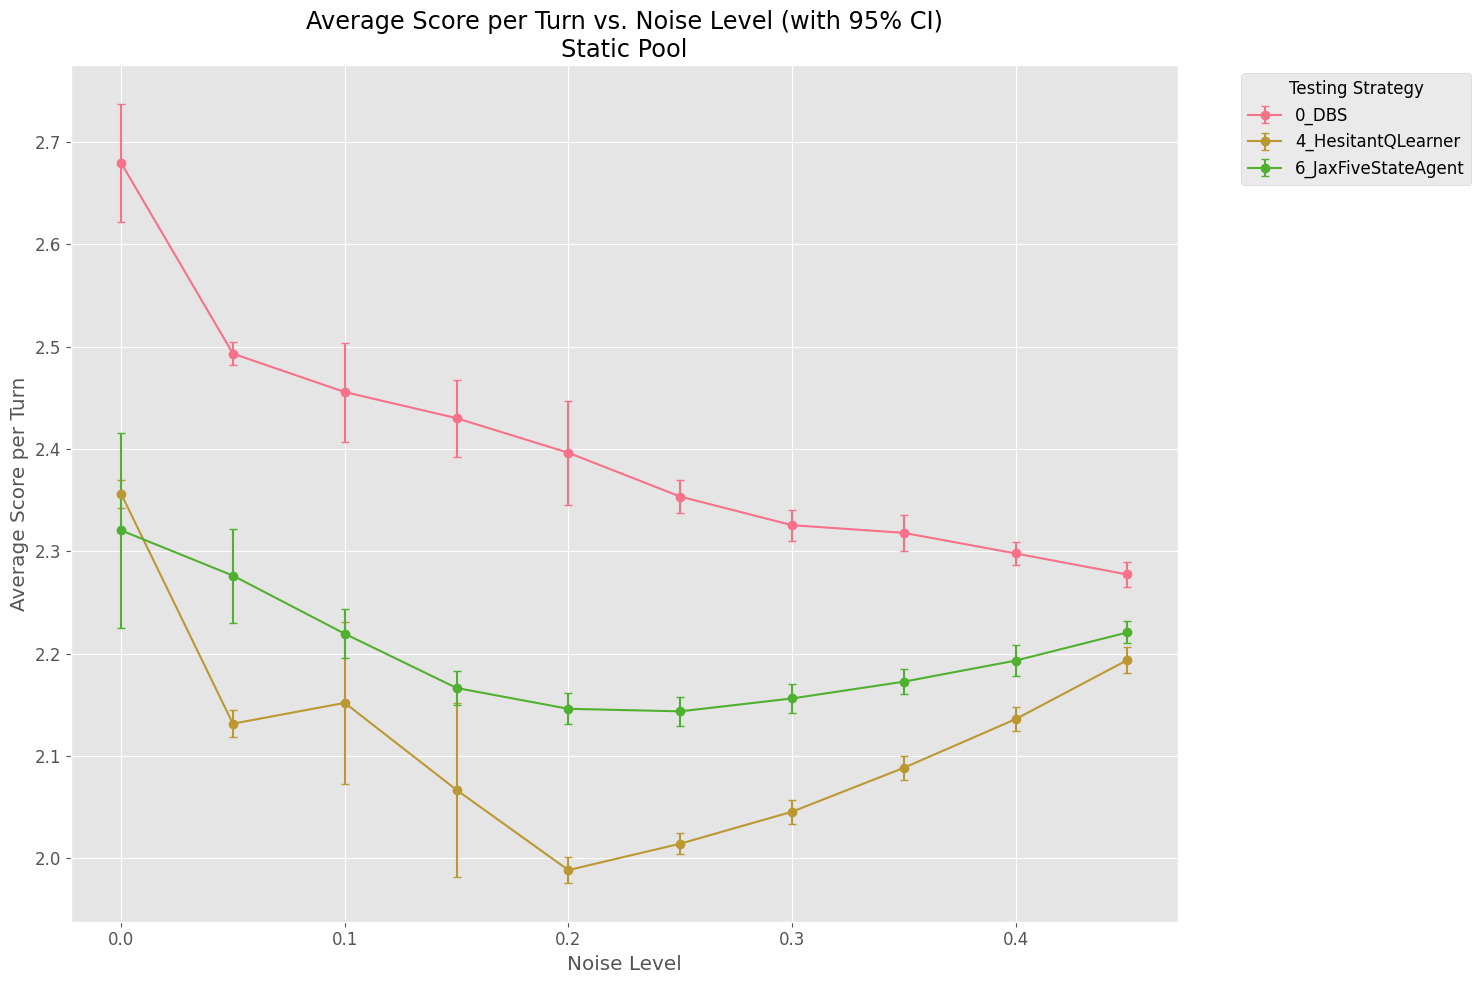

In [29]:
# For static pool
static_scores_with_ci = calculate_average_scores_with_ci(static_tournament_results)
print(static_scores_with_ci.head())
plot_score_vs_noise_with_ci(static_scores_with_ci, title="Static Pool")

0_DBS
10_AdaptiveTitForTat
11_GTFT
12_ContriteTitForTat
13_StochasticWSLS
14_WinStayLoseShift
1_RiskyQLearner
2_ArrogantQLearner
3_CautiousQLearner
4_HesitantQLearner
5_JaxFiveStateAgent
6_JaxFiveStateAgent
7_JaxFactorizedAgent
8_JaxFactorizedAgent
9_APavlov2011


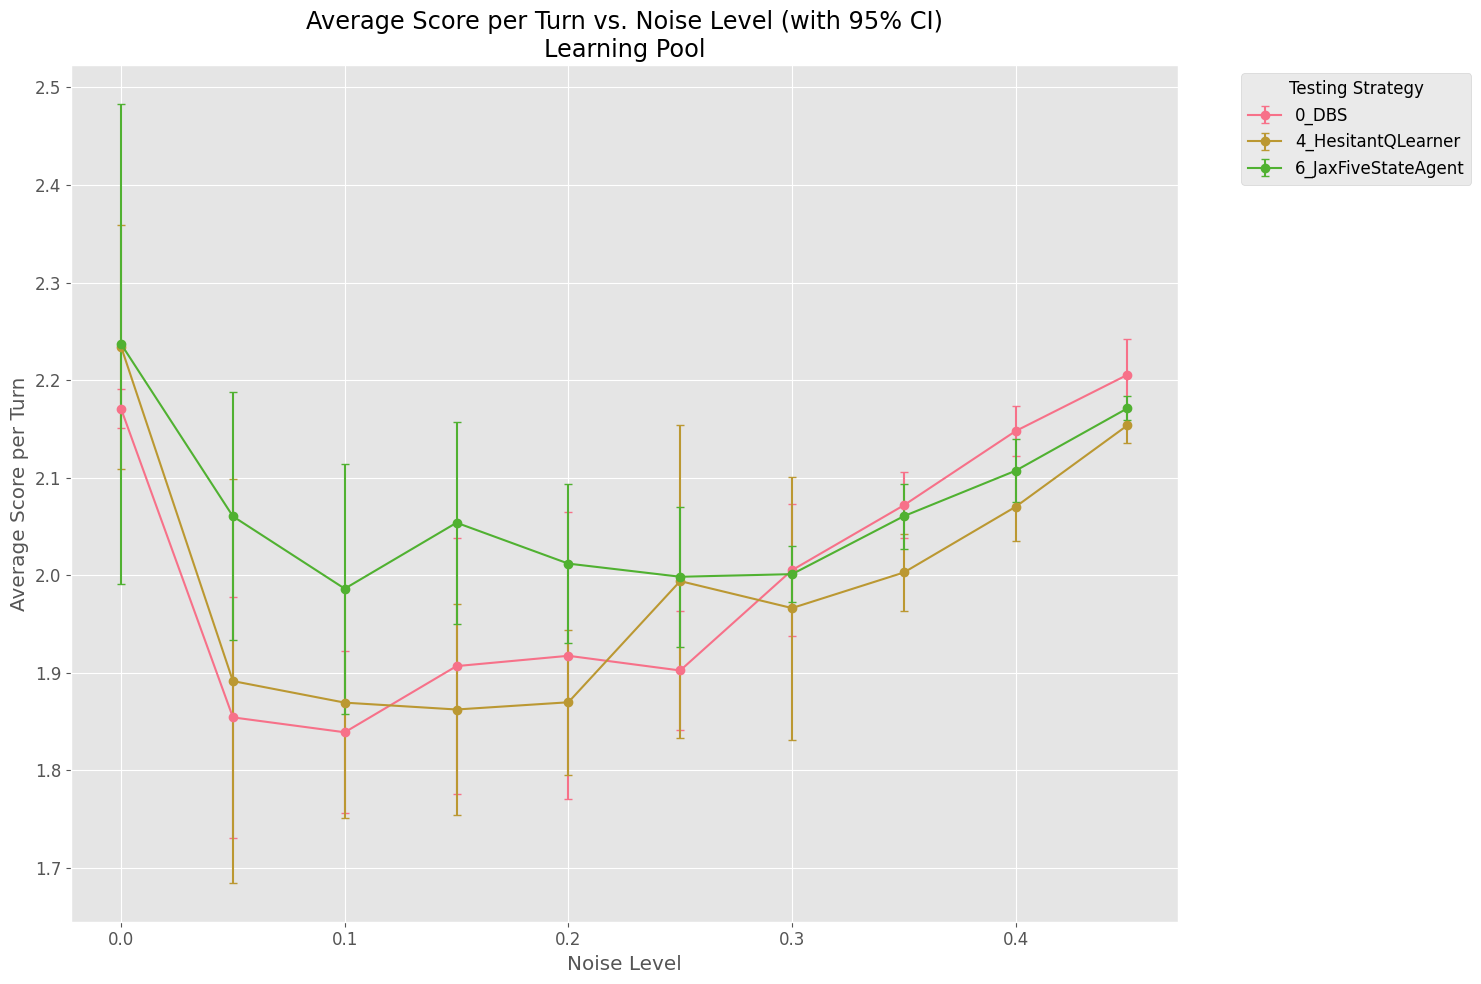

In [30]:
# For learning pool
learn_scores_with_ci = calculate_average_scores_with_ci(learn_tournament_results)
plot_score_vs_noise_with_ci(learn_scores_with_ci, title="Learning Pool")

In [31]:
static_tournament_results[static_tournament_results['testing_strategy'] == "0_DBS"].head()

,Interaction index,Player index,Opponent index,Repetition,Player name,Opponent name,Actions,Score,Score difference,Turns,...,DD to D count,Good partner,Intended Actions,strategy_id,strategy_name,testing_strategy,noise_level,repetition_id,player_name_clean,opponent_name_clean
0,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
1,0,0,0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5","DBS: 0.75, 3, 4, 3, 5"
2,1,0,1,0,"DBS: 0.75, 3, 4, 3, 5",Cooperator,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Cooperator
3,1,1,0,0,Cooperator,"DBS: 0.75, 3, 4, 3, 5",CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,4500,0,1500,...,0,1,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...,0,DBS,0_DBS,0.0,0,Cooperator,"DBS: 0.75, 3, 4, 3, 5"
4,2,0,2,0,"DBS: 0.75, 3, 4, 3, 5",Defector,CCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,1496,-20,1500,...,1495,1,CCCCDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDDD...,0,DBS,0_DBS,0.0,0,"DBS: 0.75, 3, 4, 3, 5",Defector


In [32]:
def calculate_cc_rate(tournament_data):
    """
    Calculate the cooperation rate for each testing strategy across all repetitions and opponents.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    print(testing_performance.head())
    
calculate_cc_rate(static_tournament_results)

   Interaction index  Player index  Opponent index  Repetition  \
0                  0             0               0           0   
1                  0             0               0           0   
2                  1             0               1           0   
4                  2             0               2           0   
6                  3             0               3           0   

             Player name          Opponent name  \
0  DBS: 0.75, 3, 4, 3, 5  DBS: 0.75, 3, 4, 3, 5   
1  DBS: 0.75, 3, 4, 3, 5  DBS: 0.75, 3, 4, 3, 5   
2  DBS: 0.75, 3, 4, 3, 5             Cooperator   
4  DBS: 0.75, 3, 4, 3, 5               Defector   
6  DBS: 0.75, 3, 4, 3, 5            Tit For Tat   

                                             Actions  Score  Score difference  \
0  CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...   4500                 0   
1  CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...   4500                 0   
2  CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC... 

In [33]:
def calculate_average_cc_rate_with_ci(tournament_data):
    """
    Calculate average scores for each testing strategy across all repetitions and opponents,
    including 95% confidence intervals.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    # First, calculate the average score per turn for each repetition
    rep_avg_scores = testing_performance.groupby(
        ['testing_strategy', 'noise_level', 'repetition_id']
    )['CC count'].mean().reset_index()

    # Now, calculate the mean, std, and count over the repetitions
    
    def agg_with_ci(x):
        mean = x.mean()
        std = x.std(ddof=1) # Use ddof=1 for sample standard deviation
        n = x.count()
        if n > 1:
            # Calculate 95% confidence interval
            se = std / np.sqrt(n)
            # t-distribution critical value for 95% CI
            t_crit = stats.t.ppf(0.975, df=n-1)
            ci_lower = mean - t_crit * se
            ci_upper = mean + t_crit * se
        else:
            se = np.nan
            t_crit = np.nan
            ci_lower = mean
            ci_upper = mean
            
        return pd.Series({
            'mean_score': mean,
            'std_dev': std,
            'n_reps': n,
            'se': se,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

    
    # The result of apply can sometimes be a stacked series. We unstack it.
    overall_avg_with_ci = rep_avg_scores.groupby(
        ['testing_strategy', 'noise_level']
    )['CC count'].apply(agg_with_ci).unstack().reset_index()
    
    return overall_avg_with_ci

def plot_cc_rate_vs_noise_with_ci(avg_scores_df, title=""):
    """
    Plot average scores per testing strategy against noise level, with 95% CI error bars.
    """
    plt.figure(figsize=(15, 10))
    
    # Use a color palette
    # palette = sns.color_palette("husl", len(avg_scores_df['testing_strategy'].unique()))
    
    for i, strategy in enumerate(avg_scores_df['testing_strategy'].unique()):
        print(strategy)
        if strategy not in [
            "0_DBS", 
            # "12_ContriteTitForTat",
            "4_HesitantQLearner",
            # "5_JaxFiveStateAgent",
            "6_JaxFiveStateAgent",
            # "7_JaxFactorizedAgent",
            # "8_JaxFactorizedAgent",
            # "9_APavlov2011",
            
        ]:
            continue
        strategy_data = avg_scores_df[avg_scores_df['testing_strategy'] == strategy]
        
        # Calculate the error size from the confidence interval for plt.errorbar
        y_error = strategy_data['mean_score'] - strategy_data['ci_lower']
        
        plt.errorbar(x=strategy_data['noise_level'], 
                     y=strategy_data['mean_score'], 
                     yerr=y_error,
                     label=strategy,
                     marker='o',
                     linestyle='-',
                     capsize=3, # Add caps to the error bars for visibility
                     )

    plt.title(f'Average Score per Turn vs. Noise Level (with 95% CI)\n{title}')
    plt.xlabel('Noise Level')
    plt.ylabel('Average Score per Turn')
    plt.legend(title='Testing Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()



  testing_strategy  noise_level   mean_score    std_dev  n_reps         se  \
0            0_DBS         0.00  1088.715789  32.540505     5.0  14.552556   
1            0_DBS         0.05   433.821053   9.060936     5.0   4.052174   
2            0_DBS         0.10   374.126316  30.947203     5.0  13.840010   
3            0_DBS         0.15   339.642105  36.616781     5.0  16.375522   
4            0_DBS         0.20   320.010526  19.539413     5.0   8.738291   

      ci_lower     ci_upper  
0  1048.311416  1129.120163  
1   422.570415   445.071690  
2   335.700288   412.552343  
3   294.176367   385.107844  
4   295.749141   344.271911  
0_DBS
10_AdaptiveTitForTat
11_GTFT
12_ContriteTitForTat
13_StochasticWSLS
14_WinStayLoseShift
1_RiskyQLearner
2_ArrogantQLearner
3_CautiousQLearner
4_HesitantQLearner
5_JaxFiveStateAgent
6_JaxFiveStateAgent
7_JaxFactorizedAgent
8_JaxFactorizedAgent
9_APavlov2011


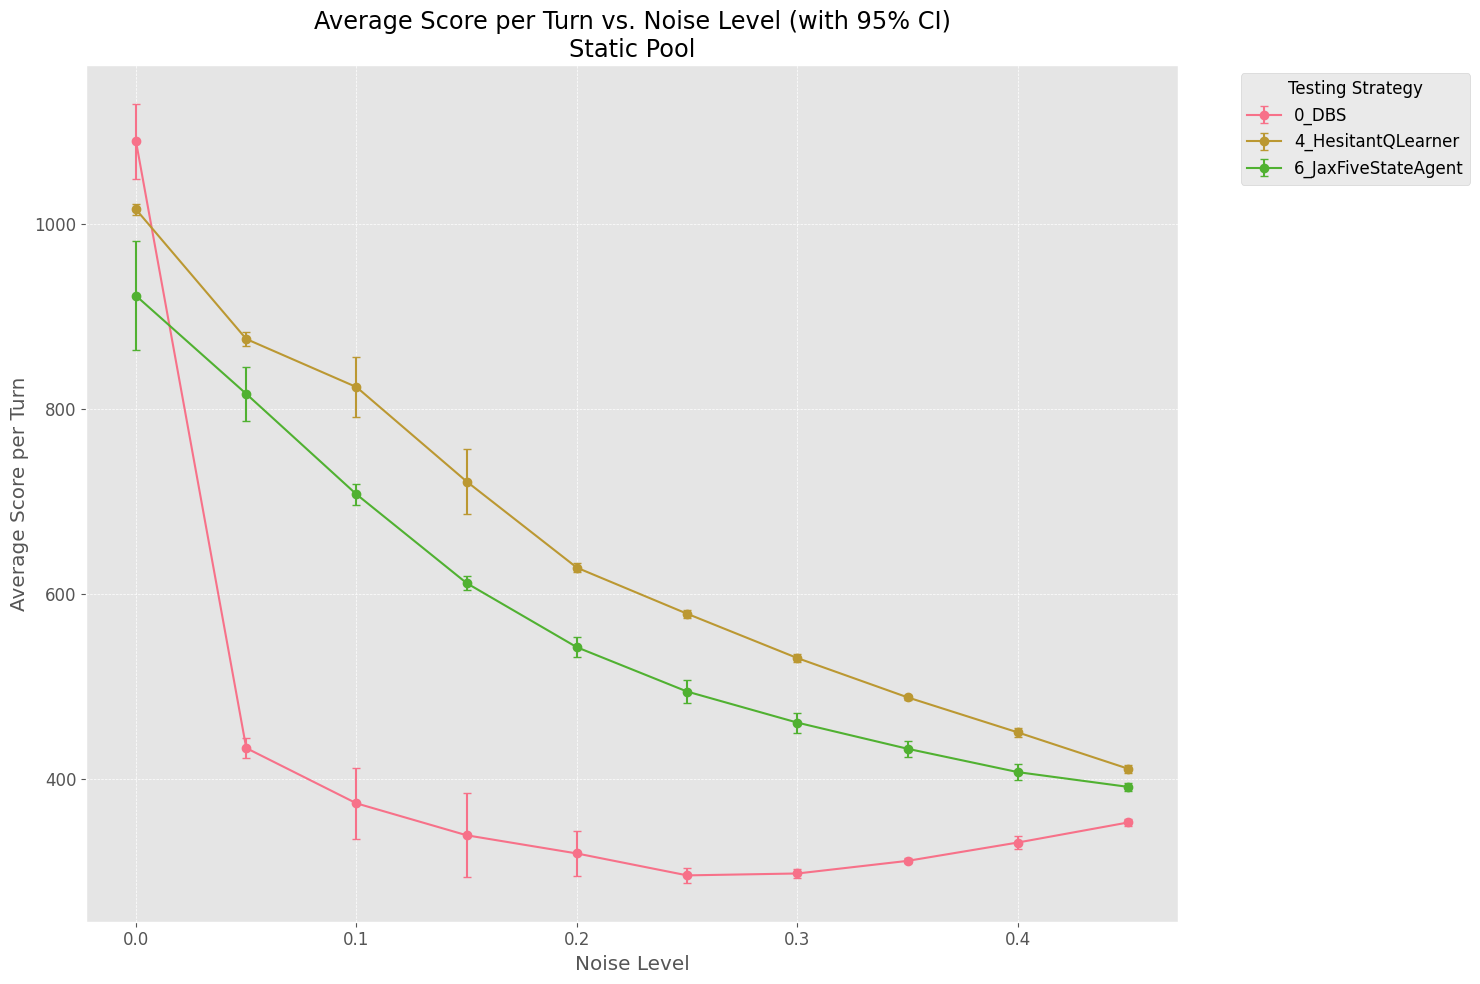

In [34]:
# For static pool
static_scores_with_ci = calculate_average_cc_rate_with_ci(static_tournament_results)
print(static_scores_with_ci.head())
plot_cc_rate_vs_noise_with_ci(static_scores_with_ci, title="Static Pool")

  testing_strategy  noise_level  mean_score    std_dev  n_reps         se  \
0            0_DBS         0.00      779.32  21.091515     5.0   9.432412   
1            0_DBS         0.05      476.12  76.496614     5.0  34.210326   
2            0_DBS         0.10      414.30  56.277749     5.0  25.168174   
3            0_DBS         0.15      365.28  46.475284     5.0  20.784379   
4            0_DBS         0.20      318.32  74.910593     5.0  33.501036   

     ci_lower    ci_upper  
0  753.131425  805.508575  
1  381.136908  571.103092  
2  344.421946  484.178054  
3  307.573313  422.986687  
4  225.306213  411.333787  
0_DBS
10_AdaptiveTitForTat
11_GTFT
12_ContriteTitForTat
13_StochasticWSLS
14_WinStayLoseShift
1_RiskyQLearner
2_ArrogantQLearner
3_CautiousQLearner
4_HesitantQLearner
5_JaxFiveStateAgent
6_JaxFiveStateAgent
7_JaxFactorizedAgent
8_JaxFactorizedAgent
9_APavlov2011


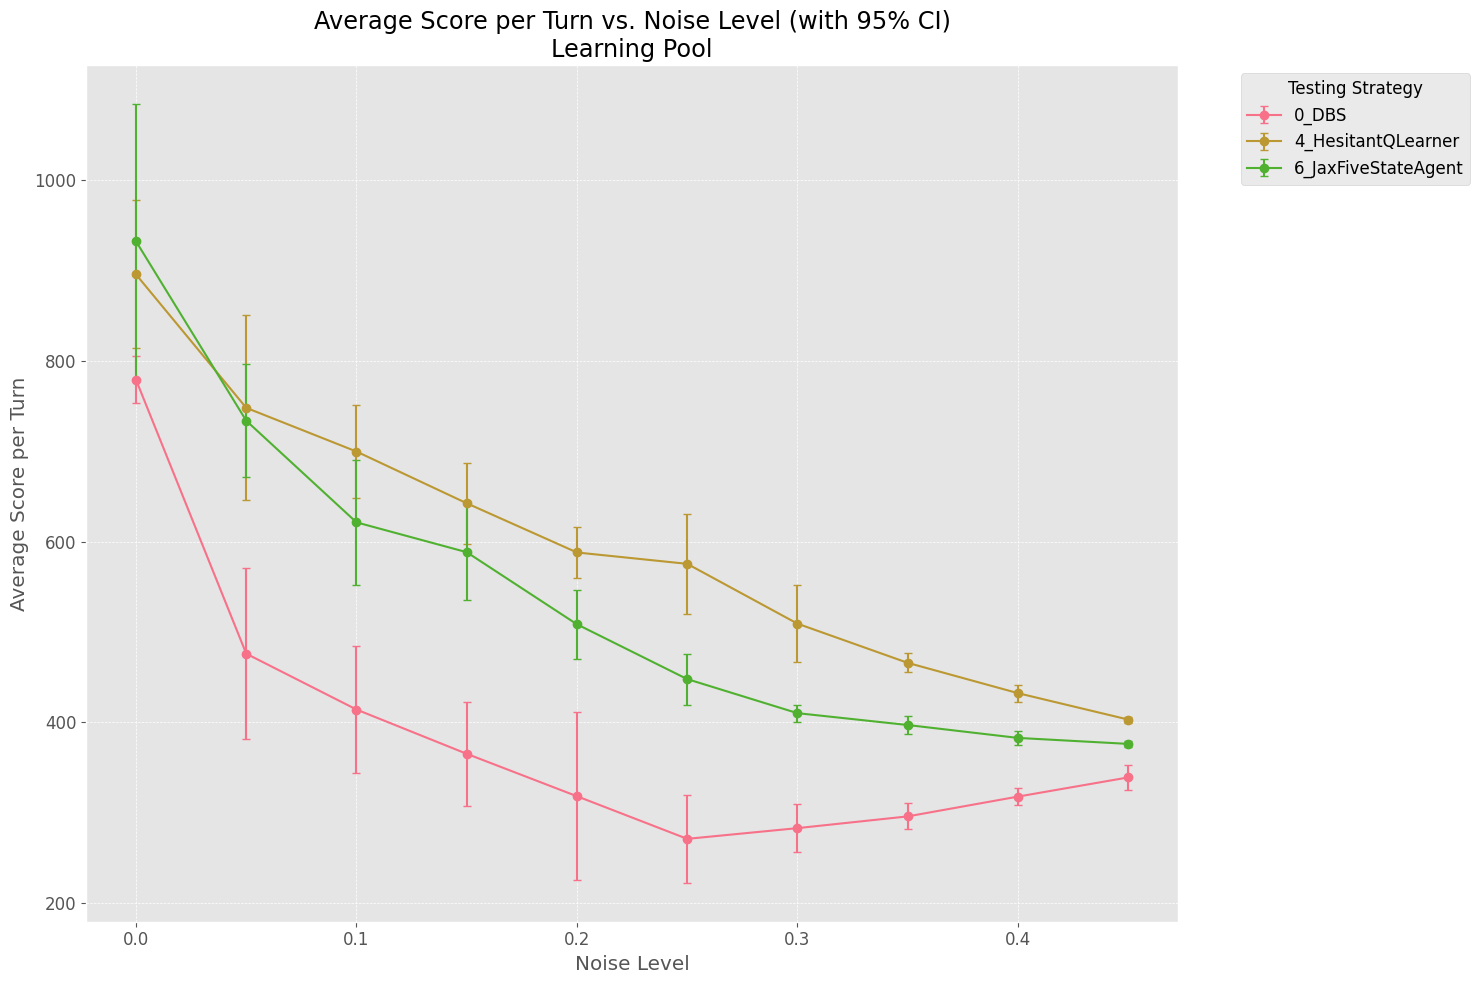

In [35]:
# For learning pool
static_scores_with_ci = calculate_average_cc_rate_with_ci(learn_tournament_results)
print(static_scores_with_ci.head())
plot_cc_rate_vs_noise_with_ci(static_scores_with_ci, title="Learning Pool")